In [1]:
# Environment setup
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "config").is_dir() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"Could not find project root from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mac/Studying/OTTO/scenario_generator


In [2]:
# Load labels and signals for the seed scenario
import pandas as pd

DATA_DIR = PROJECT_ROOT / "data" / "suv_b"
SCENARIO_SLUG = "highway_cruise_with_brake_wear"

signals_df = pd.read_csv(DATA_DIR / f"{SCENARIO_SLUG}.signals.csv")
labels_df  = pd.read_csv(DATA_DIR / f"{SCENARIO_SLUG}.labels.csv")

print(f"signals_df:  {signals_df.shape}")
print(f"labels_df:   {labels_df.shape}")
print()
print("signals columns:", list(signals_df.columns))
print("labels columns: ", list(labels_df.columns))

signals_df:  (9000, 10)
labels_df:   (15300, 9)

signals columns: ['time_s', 'timestamp_ms', 'engine_rpm', 'throttle_position', 'coolant_temperature', 'brake_pressure', 'brake_pedal', 'wheel_speed', 'vehicle_speed', 'longitudinal_acceleration']
labels columns:  ['timestamp_ms', 'can_id', 'is_fault', 'fault_count', 'severity_max', 'fault_ids', 'fault_types', 'physical_categories', 'observable_effects']


In [3]:
# Align labels to signal timesteps
# labels_df is per-frame; multiple frames share the same timestamp.
# We reduce to one row per timestamp: is_fault = 1 if any frame is faulty.

labels_per_ts = (
    labels_df
    .groupby("timestamp_ms", as_index=False)
    .agg(
        is_fault=("is_fault", "max"),
        fault_count=("fault_count", "max"),
        severity_max=("severity_max", "max"),
        fault_ids=("fault_ids", lambda s: ";".join(sorted(set(
            fid for x in s.dropna() if x for fid in x.split(";")
        )))),
    )
)

# Join onto signals by timestamp_ms
data = signals_df.merge(labels_per_ts, on="timestamp_ms", how="left")
data["is_fault"] = data["is_fault"].fillna(0).astype(int)
data["fault_count"] = data["fault_count"].fillna(0).astype(int)
data["severity_max"] = data["severity_max"].fillna(0.0)

print(f"Aligned rows: {len(data)}")
print(f"Faulty rows:  {data['is_fault'].sum():,}  ({100 * data['is_fault'].mean():.2f}%)")
print()
print(data.head(3).to_string(index=False))

Aligned rows: 9000
Faulty rows:  4,900  (54.44%)

 time_s  timestamp_ms  engine_rpm  throttle_position  coolant_temperature  brake_pressure  brake_pedal  wheel_speed  vehicle_speed  longitudinal_acceleration  is_fault  fault_count  severity_max fault_ids
   0.00             0 2253.315179               55.0            20.000000             0.0          0.0     0.000000       0.000000                    3.31992         0            0           0.0          
   0.01            10 2252.788056               55.0            20.002333             0.0          0.0     0.119517       0.119517                    3.31992         0            0           0.0          
   0.02            20 2251.747479               55.0            20.004667             0.0          0.0     0.239034       0.239034                    3.31992         0            0           0.0          


In [4]:
# Define features and time-based train/test split
FEATURES = [
    "engine_rpm",
    "throttle_position",
    "coolant_temperature",
    "brake_pressure",
    "brake_pedal",
    "wheel_speed",
    "vehicle_speed",
    "longitudinal_acceleration",
]

X = data[FEATURES].values
y = data["is_fault"].values

# Time-based split: first 60% train, last 40% test
n = len(data)
split_idx = int(0.6 * n)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
t_train, t_test = data["time_s"].values[:split_idx], data["time_s"].values[split_idx:]

print(f"Total rows:  {n}")
print(f"Train rows:  {len(X_train)}  ({100 * len(X_train) / n:.1f}%)")
print(f"Test rows:   {len(X_test)}   ({100 * len(X_test) / n:.1f}%)")
print()
print(f"Train class balance:  {y_train.sum()} faulty / {len(y_train)} total  ({100 * y_train.mean():.2f}%)")
print(f"Test class balance:   {y_test.sum()} faulty / {len(y_test)} total  ({100 * y_test.mean():.2f}%)")
print()
print(f"Train time range: {t_train[0]:.2f} – {t_train[-1]:.2f} s")
print(f"Test time range:  {t_test[0]:.2f} – {t_test[-1]:.2f} s")

Total rows:  9000
Train rows:  5400  (60.0%)
Test rows:   3600   (40.0%)

Train class balance:  1600 faulty / 5400 total  (29.63%)
Test class balance:   3300 faulty / 3600 total  (91.67%)

Train time range: 0.00 – 53.99 s
Test time range:  54.00 – 89.99 s


In [5]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

print(f"Trained on {len(X_train)} samples")
print(f"Classes: {clf.classes_}")
print(f"Feature importances will be shown below.")

Trained on 5400 samples
Classes: [0 1]
Feature importances will be shown below.


In [6]:
# Evaluation metrics
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_recall_curve,
)
import numpy as np

# Probability of the positive class
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Primary metric
auc_pr = average_precision_score(y_test, y_proba)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"AUC-PR:  {auc_pr:.4f}   (primary metric — imbalanced-friendly)")
print(f"AUC-ROC: {auc_roc:.4f}   (secondary metric)")
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix (threshold=0.5):")
print(f"  TN={tn:>6}   FP={fp:>6}")
print(f"  FN={fn:>6}   TP={tp:>6}")
print()

# Precision / recall / F1
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4, target_names=["clean", "fault"]))

# Store for later cells
metrics = {
    "auc_pr": auc_pr,
    "auc_roc": auc_roc,
    "y_proba": y_proba,
    "y_pred": y_pred,
    "cm": cm,
}

AUC-PR:  0.9507   (primary metric — imbalanced-friendly)
AUC-ROC: 0.6656   (secondary metric)

Confusion matrix (threshold=0.5):
  TN=     0   FP=   300
  FN=   441   TP=  2859

Classification report:
              precision    recall  f1-score   support

       clean     0.0000    0.0000    0.0000       300
       fault     0.9050    0.8664    0.8853      3300

    accuracy                         0.7942      3600
   macro avg     0.4525    0.4332    0.4426      3600
weighted avg     0.8296    0.7942    0.8115      3600



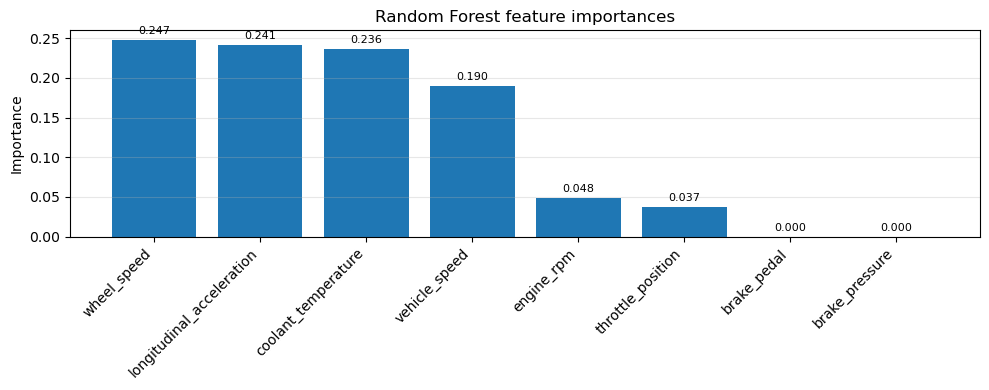

signal                          importance
---------------------------------------------
wheel_speed                     0.2474
longitudinal_acceleration       0.2414
coolant_temperature             0.2362
vehicle_speed                   0.1896
engine_rpm                      0.0481
throttle_position               0.0374
brake_pedal                     0.0000
brake_pressure                  0.0000


In [7]:
# Feature importances
import matplotlib.pyplot as plt

importances = clf.feature_importances_
order = np.argsort(importances)[::-1]
sorted_features = [FEATURES[i] for i in order]
sorted_importances = importances[order]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(FEATURES)), sorted_importances, color="tab:blue")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(sorted_features, rotation=45, ha="right")
ax.set_ylabel("Importance")
ax.set_title("Random Forest feature importances")
ax.grid(alpha=0.3, axis="y")

# Annotate each bar
for bar, imp in zip(bars, sorted_importances):
    ax.text(bar.get_x() + bar.get_width() / 2, imp + 0.005,
            f"{imp:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Print sorted
print(f"{'signal':30s}  importance")
print("-" * 45)
for f, imp in zip(sorted_features, sorted_importances):
    print(f"{f:30s}  {imp:.4f}")

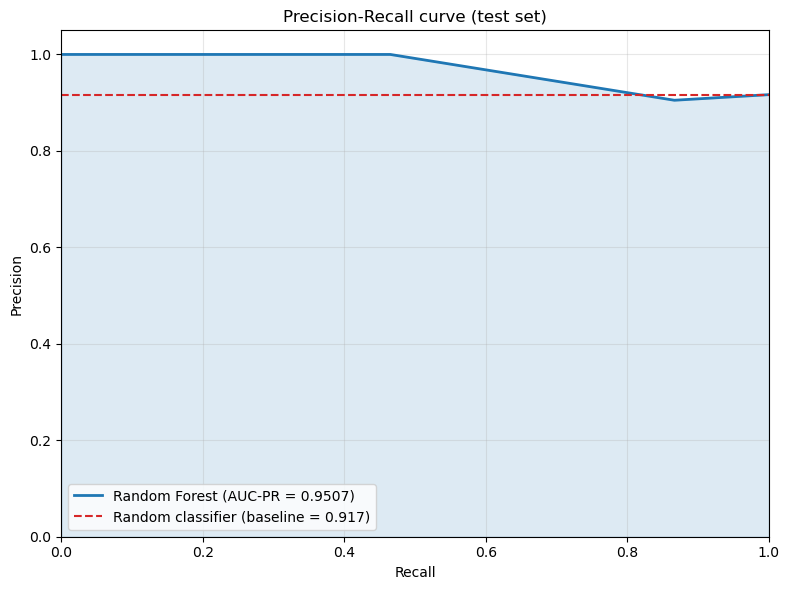

Test-set class balance:  91.67% faulty
Random classifier AUC-PR:  0.9167
Our model AUC-PR:          0.9507
Improvement factor:        1.04x


In [ ]:
# Precision-Recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color="tab:blue", linewidth=2,
        label=f"Random Forest (AUC-PR = {auc_pr:.4f})")
ax.fill_between(recall, 0, precision, color="tab:blue", alpha=0.15)

# Baseline: class prevalence
baseline = y_test.mean()
ax.axhline(baseline, color="tab:red", linestyle="--",
           label=f"Random classifier (baseline = {baseline:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve (test set)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Test-set class balance:  {100 * baseline:.2f}% faulty")
print(f"Random classifier AUC-PR:  {baseline:.4f}")
print(f"Our model AUC-PR:          {auc_pr:.4f}")
print(f"Improvement factor:        {auc_pr / baseline:.2f}x")

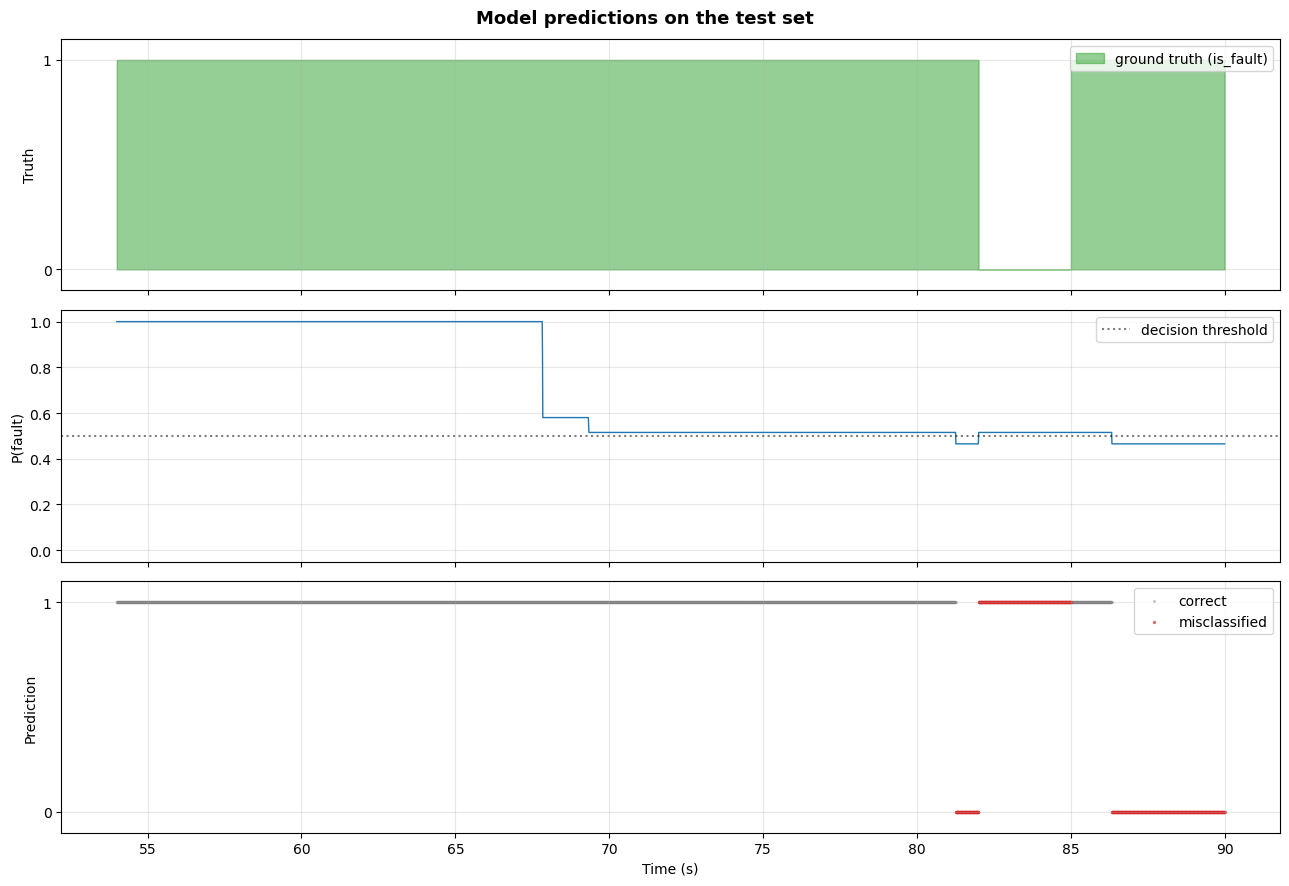

Total test rows:      3600
Misclassified rows:   741  (20.58%)


In [9]:
# Predictions vs. ground truth around fault boundaries
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
test_time = t_test

# Ground truth
axes[0].fill_between(test_time, 0, y_test,
                     color="tab:green", alpha=0.5, step="mid",
                     label="ground truth (is_fault)")
axes[0].set_ylabel("Truth")
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_yticks([0, 1])
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Predicted probability
axes[1].plot(test_time, y_proba, color="tab:blue", linewidth=1.0)
axes[1].axhline(0.5, color="black", linestyle=":", alpha=0.5, label="decision threshold")
axes[1].set_ylabel("P(fault)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

# Prediction vs. truth (errors highlighted)
correct = (y_pred == y_test)
axes[2].scatter(test_time[correct], y_pred[correct], s=2, alpha=0.3,
                color="tab:gray", label="correct")
axes[2].scatter(test_time[~correct], y_pred[~correct], s=2, alpha=0.6,
                color="tab:red", label="misclassified")
axes[2].set_ylabel("Prediction")
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_yticks([0, 1])
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

fig.suptitle("Model predictions on the test set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Error count
n_errors = (~correct).sum()
print(f"Total test rows:      {len(y_test)}")
print(f"Misclassified rows:   {n_errors}  ({100 * n_errors / len(y_test):.2f}%)")

In [10]:
# Sanity check: which signals should the model rely on?
print("Expected behavior:")
print("  The fault reduces braking effectiveness → cascade affects:")
print("    - longitudinal_acceleration")
print("    - vehicle_speed")
print("    - wheel_speed")
print("    - engine_rpm")
print()
print("  The fault should NOT change:")
print("    - throttle_position")
print("    - brake_pedal")
print("    - brake_pressure")
print("    - coolant_temperature")
print()

expected_important = {
    "longitudinal_acceleration", "vehicle_speed",
    "wheel_speed", "engine_rpm",
}
expected_unimportant = {
    "throttle_position", "brake_pedal",
    "brake_pressure", "coolant_temperature",
}

# Top 4 features by importance
top_features = set(sorted_features[:4])
print(f"Top 4 features by importance:  {sorted(top_features)}")
print(f"Expected-important set:        {sorted(expected_important)}")
print()

# High-importance signals that aren't expected
unexpected_high = top_features - expected_important
if unexpected_high:
    print(f"⚠️  Unexpectedly high importance: {sorted(unexpected_high)}")
    print(f"    These signals shouldn't be affected by brake_pad_wear.")
else:
    print("✅ No unexpected high-importance features.")

# Low-importance signals that should be unimportant
bottom_4 = set(sorted_features[-4:])
if bottom_4 <= expected_unimportant:
    print("✅ The four least important features are all expected-unimportant.")
else:
    extra = bottom_4 - expected_unimportant
    print(f"⚠️  Some expected-unimportant features appear in the bottom 4:")
    print(f"    Unexpectedly low: {sorted(extra)}")

Expected behavior:
  The fault reduces braking effectiveness → cascade affects:
    - longitudinal_acceleration
    - vehicle_speed
    - wheel_speed
    - engine_rpm

  The fault should NOT change:
    - throttle_position
    - brake_pedal
    - brake_pressure
    - coolant_temperature

Top 4 features by importance:  ['coolant_temperature', 'longitudinal_acceleration', 'vehicle_speed', 'wheel_speed']
Expected-important set:        ['engine_rpm', 'longitudinal_acceleration', 'vehicle_speed', 'wheel_speed']

⚠️  Unexpectedly high importance: ['coolant_temperature']
    These signals shouldn't be affected by brake_pad_wear.
⚠️  Some expected-unimportant features appear in the bottom 4:
    Unexpectedly low: ['engine_rpm']


In [11]:
#  Verification summary
print("=" * 70)
print("ML BASELINE VERIFICATION")
print("=" * 70)
print()

checks = []

# 1. Data loaded and aligned
checks.append(("Signals and labels aligned", len(data) == len(signals_df)))

# 2. Both classes present in train and test
checks.append(("Both classes in train", 0 < y_train.sum() < len(y_train)))
checks.append(("Both classes in test", 0 < y_test.sum() < len(y_test)))

# 3. Model trained successfully
checks.append(("Model trained", hasattr(clf, "feature_importances_")))

# 4. AUC-PR above random
checks.append((f"AUC-PR > baseline ({auc_pr:.3f} > {y_test.mean():.3f})",
               auc_pr > y_test.mean()))

# 5. AUC-PR above a meaningful threshold
checks.append((f"AUC-PR > 0.85 ({auc_pr:.3f})", auc_pr > 0.85))

# 6. Top features include expected cascade signals
top4 = set(sorted_features[:4])
checks.append(("Top 4 features include cascade signals",
               len(top4 & expected_important) >= 3))

# 7. Expected-unimportant signals have low importance
checks.append(("Brake pressure importance is low",
               importances[FEATURES.index("brake_pressure")] < 0.1))

# Print
for name, passed in checks:
    status = "✅" if passed else "❌"
    print(f"  {status}  {name}")

all_passed = all(p for _, p in checks)
print()
if all_passed:
    print("🎉 All verification checks passed. Pipeline produces learnable data.")
else:
    print("⚠️  Some checks failed. Review the results above.")

ML BASELINE VERIFICATION

  ✅  Signals and labels aligned
  ✅  Both classes in train
  ✅  Both classes in test
  ✅  Model trained
  ✅  AUC-PR > baseline (0.951 > 0.917)
  ✅  AUC-PR > 0.85 (0.951)
  ✅  Top 4 features include cascade signals
  ✅  Brake pressure importance is low

🎉 All verification checks passed. Pipeline produces learnable data.


In [12]:
# Honest evaluation on balanced test set
import numpy as np

# Find indices of clean and faulty in the test set
idx_clean = np.where(y_test == 0)[0]
idx_fault = np.where(y_test == 1)[0]

print(f"Test set: {len(idx_clean)} clean, {len(idx_fault)} faulty")

# Subsample the majority class to match minority
rng = np.random.default_rng(42)
n_minority = len(idx_clean)
idx_fault_sub = rng.choice(idx_fault, size=n_minority, replace=False)

balanced_idx = np.concatenate([idx_clean, idx_fault_sub])
X_bal = X_test[balanced_idx]
y_bal = y_test[balanced_idx]

# Retrain on balanced data (or just re-evaluate? Retrain is cleaner)
clf_bal = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
clf_bal.fit(X_train, y_train)   # same training, but evaluate on balanced test

y_proba_bal = clf_bal.predict_proba(X_bal)[:, 1]
y_pred_bal = (y_proba_bal >= 0.5).astype(int)

from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix

print()
print(f"Balanced test set (N={len(balanced_idx)}):")
print(f"  AUC-PR:  {average_precision_score(y_bal, y_proba_bal):.4f}")
print(f"  AUC-ROC: {roc_auc_score(y_bal, y_proba_bal):.4f}")
print(f"  Confusion matrix:")
print(f"  {confusion_matrix(y_bal, y_pred_bal)}")

Test set: 300 clean, 3300 faulty

Balanced test set (N=600):
  AUC-PR:  0.7181
  AUC-ROC: 0.6783
  Confusion matrix:
  [[  0 300]
 [ 31 269]]
